#<h1><center>Lab 1 - A1</center></h1>

##	REQUIREMENTS
1.	Source code (notebook) needs to be documented.
2.	Algorithms have to be tested for several parameter values (sufficient to clearly determine performance).
3.	Experiments must be performed for all available problem instances and results compared for diferent parameter settings.
4.	Results of the experiments need to be saved in output files, indicating solution quality, parameter values used, number of runs.
5.	A report should capture the following: problem definition, algorithm used (name, steps/pseudocode), parameter setting, comparative results of experiments, discussion of results.


## Knapsack Problem
- $n$ objects, each has a value ($v$) and a weight ($w$)
- Objective: the knapsack to contain max value without exceeding max weight $W$
 - $x_i=1$ means object $i$ is selected
 - $x_i=0$ means object $j$ is not selected

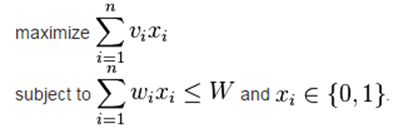


## WORK DURING THE LAB
1.	Exhaustive search: generate all possible binary strings of size N and print them on the screen. Test the code for different values of N.
2.	Read data for the knapsack problem.
3.	Generate a random solution for the knapsack problem and verify its quality.

**Points for the work during the lab: 25p**


In [ ]:
#1

def generate_binary_strings(n, prefix="", sols = []):
    if n == 0:
        print(prefix)
        sols.append(prefix)
    else:
        generate_binary_strings(n - 1, prefix + "0", sols)
        generate_binary_strings(n - 1, prefix + "1", sols)
       
generate_binary_strings(3)

In [ ]:
#2
def load_data(file_name: str) -> "list[tuple[int, int]]":
  weights_and_values = []
  with open(file_name) as f:
    total = int(f.readline())
    for _ in range(total) :
        values = f.readline().split()
        # print(values)
        n2 = int(values[1])
        n3 = int(values[2])
        weights_and_values.append((n2, n3))
    
    max_value = int(f.readline())
    
  return total, weights_and_values, max_value
total, weights_values, max_value = load_data("knapsack-20.txt")
print(total)
print(weights_values)
print(max_value)

In [ ]:
#3
import random

solutions = []
generate_binary_strings(n=total, prefix="", sols=solutions)
# print(solutions)
print("My Solution")
my_choice = random.choice(solutions)
print(my_choice)


weight = 0
sum = 0
for i in range(len(my_choice)):
  value = int(my_choice[i])
  sum+=value*weights_values[i][1]
  weight+=value*weights_values[i][0]
  
print(f"Total value reacehd={sum}")
print(f"Weights={weight}, max_weight = {max_value}")
  

##	ASSIGNMENT A1
1.	Implement a random search method for the knapsack problem.
 1.	From k random solutions, the method should return the best one.
 1.	Test the method for different values of k.
 1.	Perform experiments for knapsack instances of size 20 and 200.
1.	Submit source code and report.

**Deadline to submit A1: Lab 2**
**Points for A1: 25p**


In [14]:
import random
def generate_binary_strings(n : int, k : int):
    """"
        Generates k tuples of size n with the values [0, 1].
        Where 1 represents adding a certain item to the solution and
        0 otherwise.
        
    Args:
        n (int): the size of the list
        k (int) : the number of solutions generated
        
    Returns:
        set : returns a set of size k of tuples of size n
    """
    solutions = set()
    while len(solutions) < k :
        solutions.add(tuple(random.randint(0,1) for _ in range(n)))
    return solutions
        
generate_binary_strings(10, 3)
    

{(1, 1, 1, 0, 0, 0, 0, 1, 1, 1),
 (1, 1, 1, 0, 0, 0, 1, 1, 0, 1),
 (1, 1, 1, 0, 1, 0, 0, 0, 1, 0)}

In [16]:
#2
def load_data(file_name: str) :
    """"
        Helper functions that extracts the data from the input files.
        The format based on which it extracts can be seen at 'knapsack-20.txt'
        The first line holds the nr of total objects n, then n lines represeting 
        the index, value and weight of the values, then the max_weight is on the last line. 
    Args:
        file_name (str): Input file for extracting data

    Returns:
        int : The total number of objects 
        list[tuple[int, int]]: The results consists of the n tuples(represnting (value, weight) pairs)
        int : The maximum value for the total weight
    """
    weights_and_values = []
    with open(file_name) as f:
        total = int(f.readline())
        for _ in range(total) :
            values = f.readline().split()
            # print(values)
            n2 = int(values[1])
            n3 = int(values[2])
            weights_and_values.append((n2, n3))
        
        max_value = int(f.readline())
    
    return total, weights_and_values, max_value


total, weights_values, max_value = load_data("knapsack-20.txt")

In [41]:
def compute_value_for_solution(solution :tuple, max_value_weight, weights_values:list[tuple]) :
    """For each solution generated it computes the total value accumulated and
    the weight it reaches , if the weight is valid it return the maximum one, otherwise -1.

    Args:
        solution (tuple): The tuple of size n representing the made out of 0s and 1s, representing
        whether the values are added or not.
        max_value_value (int): The maximum weight given as input
        weights_values (list[tuple]) : The input data for all the objects (value, weight) pairs
        
    Returns:
    int : Returns the total value if the weight is lower that the max_value_weight,
            otherwise returns -1
    """
    sum_values = 0
    sum_weights = 0
    
    for i in range(len(solution)) :
        sum_values+=solution[i]*weights_values[i][0]
        sum_weights+=solution[i]*weights_values[i][1]
        
    if sum_weights <= max_value_weight :
        return sum_values
    return -1

In [53]:
def solve_knapsack(file_name : str, k : int) :
    """
        With the usage of our helper functions : generate_binary_string, load_data 
        and compute_value_for_solution we load the data, generate k solution compute the value for each
        and return the highest value recorded.
        
    Args:
        file_name (str): The input file for the knapsack problem
        k (int) : The number of solutions to generate
        
    Return :
        int : The total_value of the best solution generated
    """
    n, weights_values, max_weight = load_data(file_name)
    solutions = generate_binary_strings(n, k)
    
    # print("All solutions :")
    all_solutions = [compute_value_for_solution(solution, max_weight, weights_values) for solution in solutions]
    # print(*all_solutions, sep='\n')
    
    best_solution = max(all_solutions)
    # print("And the best solution is :")
    
    return best_solution    

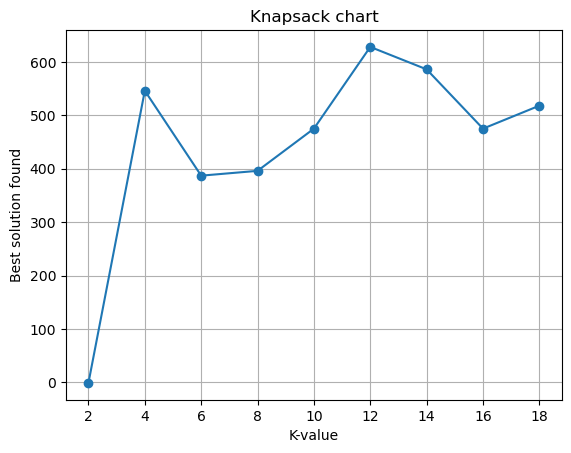

In [63]:
import matplotlib.pyplot as plt

def generate_report(input_file :str, output_file :str) :
    """
        Generates a report of the best value reached for the knapsack problem
        in discussion to the values of k, it then writes the results to a .txt file.
        Also makes a plot having x axis the value of k and y axis the best result obtained to show small increase with k

    Args:
        input_file (str) : Input file for reading, processing data and generating solutions
        output_file (str) : Output file for writting the findings
    """
    k_vals = []
    solutions_vals = []
    with open(output_file, 'a') as f :
        f.write("**Report begining :**\n")
    
    n, _, _ = load_data(input_file)
    for k in range(2, n, 2) :
        result = solve_knapsack(input_file, k)
        k_vals.append(k)
        solutions_vals.append(result)
        with open(output_file, "a") as f:
            f.write(f"k={k}, best_value={result}\n")
            
    

    plt.plot(k_vals, solutions_vals, marker='o')
    plt.title("Knapsack chart")
    plt.xlabel("K-value")
    plt.ylabel("Best solution found")
    plt.grid(True)
    plt.show()
            
generate_report('knapsack-20.txt', 'report_20.txt')